# Exploring Exoplanets: Trends and Insights from Seaborn's Planet Dataset

## 🪐 Understanding Exoplanets

### What Are Exoplanets?
**Exoplanets** (or **extrasolar planets**) are planets that orbit **stars outside our Solar System**.  
Just like Earth orbits the Sun, exoplanets orbit other stars in our galaxy — and possibly beyond.

Astronomers have confirmed **thousands of exoplanets** since the first discovery in 1992, and new ones continue to be found every year.  
These worlds come in many forms — **gas giants**, **rocky planets**, **ocean worlds**, and even **"Hot Jupiters"** that orbit extremely close to their stars.

> NASA’s Kepler mission (2009–2018) discovered thousands of exoplanets using the transit method, which is why in the Seaborn dataset, you’ll see a spike in discoveries around those years!

## Why This Dataset Is Interesting

The `planets` dataset is fascinating because it tells the story of **human discovery beyond our Solar System**.  
Each row represents a real exoplanet — a planet orbiting a distant star — and shows how it was detected, when, and with what characteristics.

It captures a remarkable scientific journey: in just a few decades, astronomers have gone from knowing **no exoplanets** to discovering **thousands** using advanced methods like the *Transit* and *Radial Velocity* techniques.

## What You’ll Learn from This Notebook

In this notebook, we’ll explore the Seaborn **planets dataset**, which contains data on over 1,000 confirmed exoplanets — planets that orbit stars beyond our Solar System.

By the end of this analysis, you will learn:

- 🧭 How to load, explore, and clean a real-world dataset using Python and Seaborn  
- 📊 How to visualize data to reveal patterns and trends  
- 🌟 How different discovery methods (Transit, Radial Velocity, Imaging, etc.) have contributed to finding exoplanets  
- ⏳ How the rate of discoveries has changed over time  
- 🪐 What relationships exist between planet characteristics such as mass, distance, and orbital period  

Beyond technical skills, you’ll also gain insights into **how astronomers discover new worlds** and how data can help us understand the universe.

In [13]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#load dataset
df = sns.load_dataset('planets')
df.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


### Here's what each column means

| 🌟 Column        | 🔍 Meaning | Example |
|-----------------|-----------|---------|
| **method** 🛰️    | The technique used to detect the exoplanet. Common methods: <br>• `Transit`: planet passes in front of its star 🌑<br>• `Radial Velocity`: star “wobbles” due to planet’s gravity ⚖️ | Transit |
| **number** 🔢    | Number of planets discovered in that system using the same method | 1 |
| **orbital_period** ⏱️ | Time for one orbit around the star (in **days**) | 3.524 |
| **mass** ⚖️      | Planet mass relative to Jupiter (in **Jupiter masses**) | 0.73 |
| **distance** 📏  | Distance from Earth to the star system (in **parsecs**, 1 pc ≈ 3.26 light-years) | 47.0 |
| **year** 📅      | Year the planet was discovered | 2011 |

> ⚠️ **Note:** Some values may be missing (`NaN`) if unknown.

In [23]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 48.6+ KB


method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

### Analysis

**Columns with missing data:** orbital_period, mass, distance

**Categorical Columns:** method

**Numeric columns:** number, orbital_period, mass, distance, year

In [24]:
df_cleaned = df.dropna(subset=['orbital_period','mass','distance'])  #cleaned the dataset by removing rows with null values
display(df_cleaned)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.30000,7.100,77.40,2006
1,Radial Velocity,1,874.77400,2.210,56.95,2008
2,Radial Velocity,1,763.00000,2.600,19.84,2011
3,Radial Velocity,1,326.03000,19.400,110.62,2007
4,Radial Velocity,1,516.22000,10.500,119.47,2009
...,...,...,...,...,...,...
640,Radial Velocity,1,111.70000,2.100,14.90,2009
641,Radial Velocity,1,5.05050,1.068,44.46,2013
642,Radial Velocity,1,311.28800,1.940,17.24,1999
649,Transit,1,2.70339,1.470,178.00,2013


## Univariate Analysis
Understand distribution of individual features

### 1) Number column

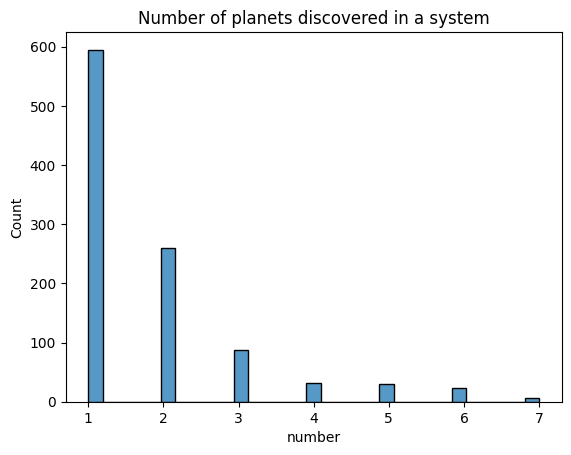

In [27]:
sns.histplot(df['number'])
plt.title("Number of planets discovered in a system")
plt.show()

### Inference
Most known exoplanetary systems have only one discovered planet, and the frequency of systems decreases as the number of planets increases. 

Multi-planet systems exist but are much less common in the dataset.

### 2) Orbital Period column

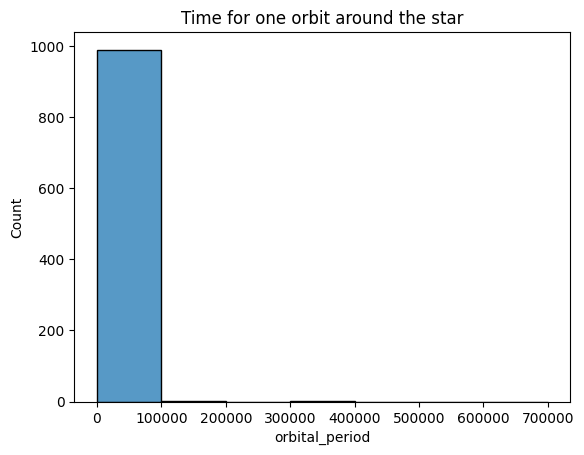

In [32]:
sns.histplot(df['orbital_period'],bins=7,binrange=(0,700000))
plt.title('Time for one orbit around the star')
plt.show()

### Inference
The majority discovered exoplanets have short orbital period

Planets with long orbital period exist but are rare in the dataset

### 3) Mass column

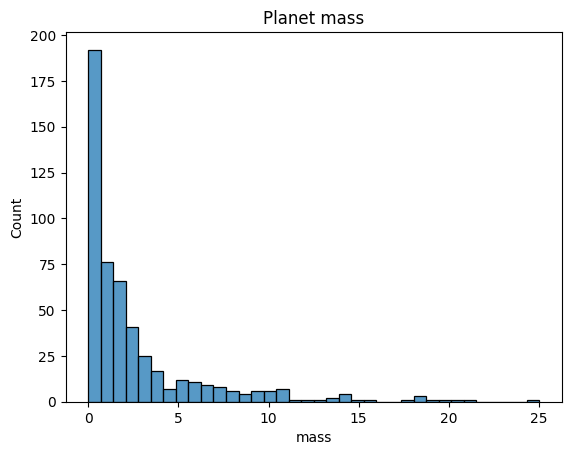

In [33]:
sns.histplot(df['mass'])
plt.title('Planet mass')
plt.show()

### Inference
Most discovered exoplanets have masses less than 1 Jupiter Mass

Very massive planets are much rare

### 4) Distance column

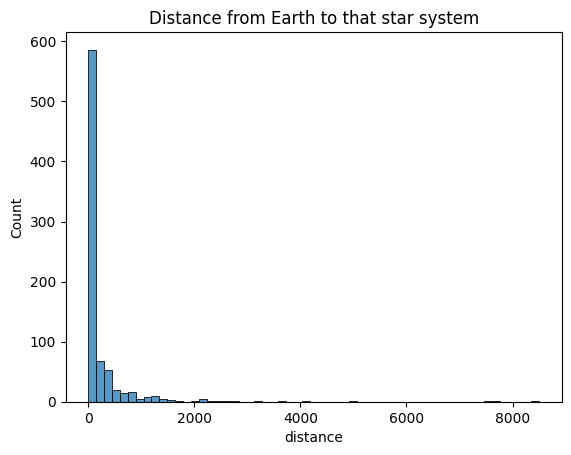

In [34]:
sns.histplot(df['distance'])
plt.title('Distance from Earth to that star system')
plt.show()

### Inference
Most discovered exoplanets orbit stars relatively close to Earth 

### 5) Year column

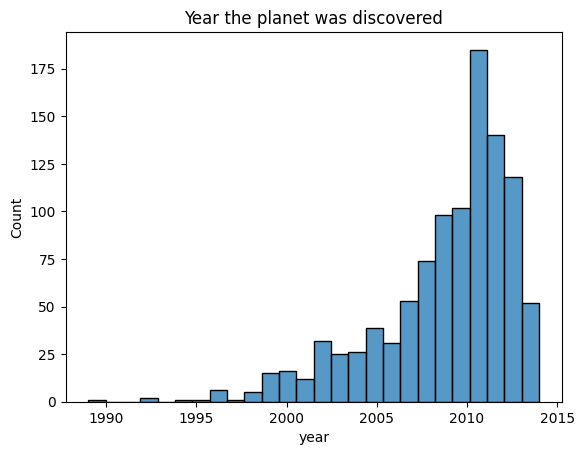

In [35]:
sns.histplot(df['year'])
plt.title('Year the planet was discovered')
plt.show()

### Inference
Most planets in the dataset were discovered after 2005

### 6) Method column

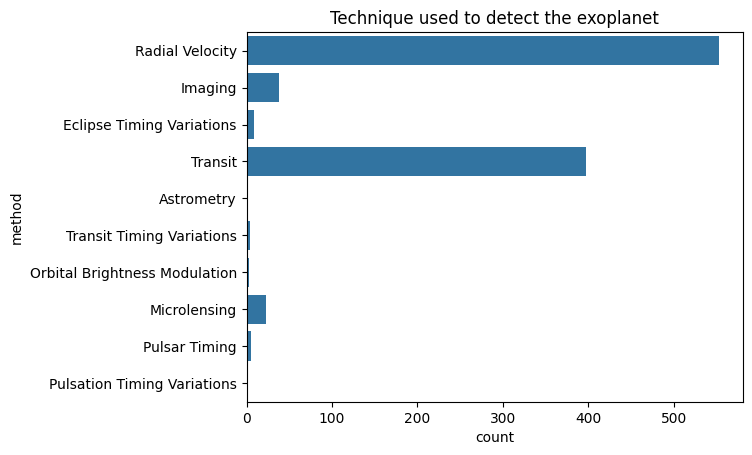

In [42]:
sns.countplot(df['method'])
plt.title('Technique used to detect the exoplanet')
plt.show()

### Inference
Most exoplanets are discovered using the Radial Velocity or Transit method

Other detection techniques contribute far fewer discoveries

### Correlation

<Axes: >

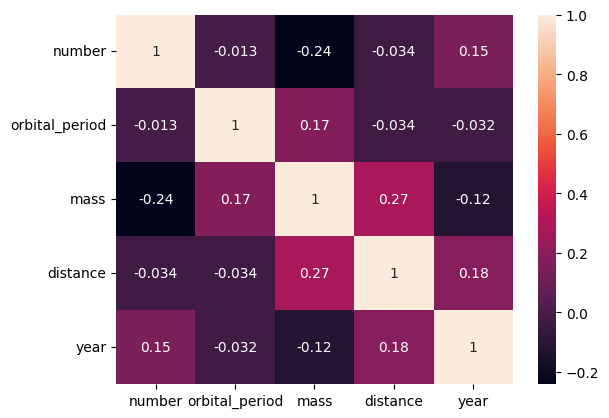

In [44]:
data = df[['number','orbital_period','mass','distance','year']]
corr_mat = data.corr()
sns.heatmap(corr_mat,annot=True)

### Inference
Most numerical variables are weakly correlated